In [1]:
# Import libraries and use seaborn for data visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load the dataset
df = pd.read_csv('data/austin_ev.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date Range: {df["timestamp"].min()} to {df["timestamp"].max()}')

Dataset Shape: 43,925 rows x 33 columns
Date Range: 2025-07-01 00:00:00 to 2025-12-31 00:00:00


In [2]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values found')

Missing Values Summary:
No missing values found


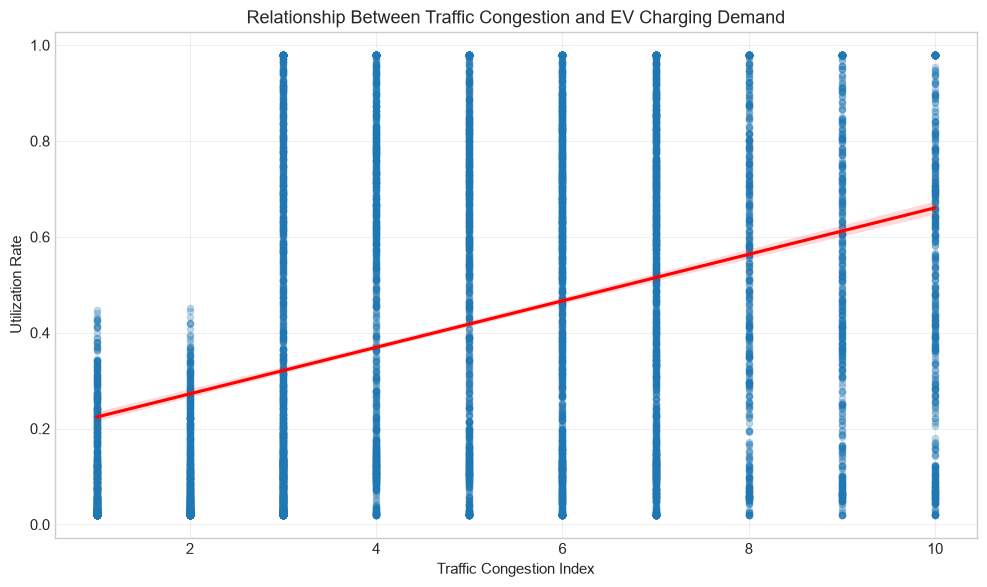

In [3]:
# Takes a random sample of the data
plot_sample = df.sample(n=10000, random_state=42)

# Create a scatter plot with a trend line
plt.figure(figsize=(10,6))
sns.regplot(
    data=plot_sample,
    x="traffic_congestion_index",
    y="utilization_rate",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color":"red"}
)

# Label the figure 
plt.title("Relationship Between Traffic Congestion and EV Charging Demand")
# Traffic intensity score from 1-10 (1-3 light, 4-6 moderate, 7-10 heavy congestion)
plt.xlabel("Traffic Congestion Index")
plt.ylabel("Utilization Rate")

plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

In [5]:
# Calculate the average utilization rate for each hour
utilization_by_hour = (
    df.groupby("hour_of_day")["utilization_rate"]
      .mean()
      .reset_index()
)

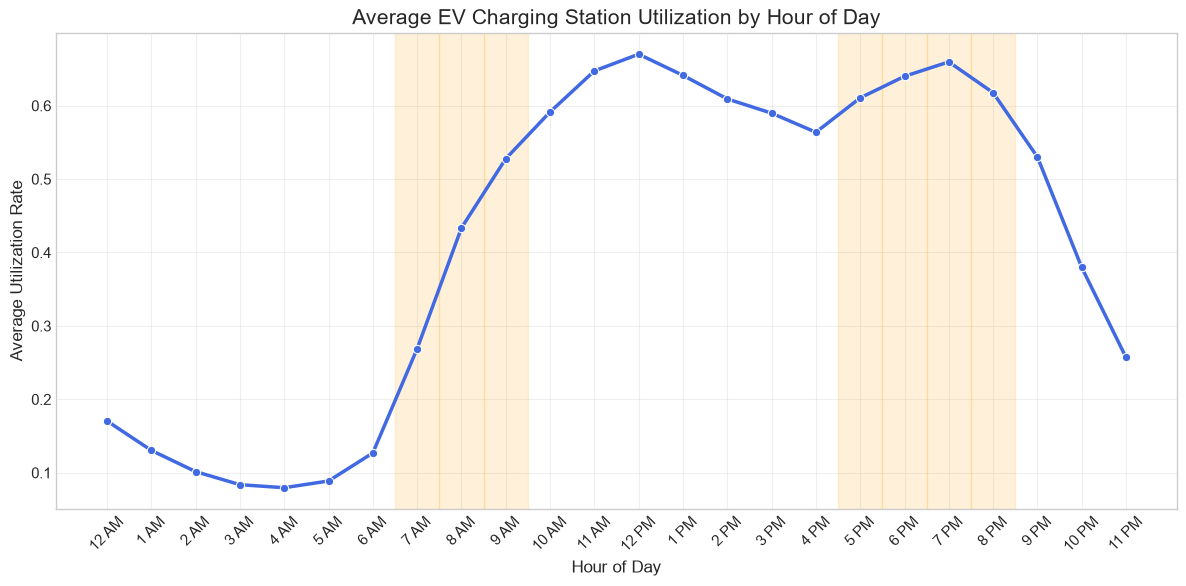

In [6]:
# Create a line graph to show the average utilization by hour 
plt.figure(figsize=(12,6))

# Plot the line graph 
sns.lineplot(
    data=utilization_by_hour,
    x="hour_of_day",
    y="utilization_rate",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

# Highlight the peak-hour periods 
peak_hours = sorted(df.loc[df["is_peak_hour"] == 1, "hour_of_day"].unique())

for hour in peak_hours:
    plt.axvspan(hour - 0.5, hour + 0.5, color="orange", alpha=0.15)

plt.title("Average EV Charging Station Utilization by Hour of Day", fontsize=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Utilization Rate", fontsize=12)

labels = [
    "12 AM","1 AM","2 AM","3 AM","4 AM","5 AM",
    "6 AM","7 AM","8 AM","9 AM","10 AM","11 AM",
    "12 PM","1 PM","2 PM","3 PM","4 PM","5 PM",
    "6 PM","7 PM","8 PM","9 PM","10 PM","11 PM"
]

plt.xticks(range(24), labels, rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

# Show the line graph 
plt.show()

In [7]:
# Check all unique charger types and count of each charger type 
df["charger_type"].unique()
df["charger_type"].value_counts()

charger_type
DC Fast Charge    17570
Tesla DC Fast     17570
Level 2            8785
Name: count, dtype: int64

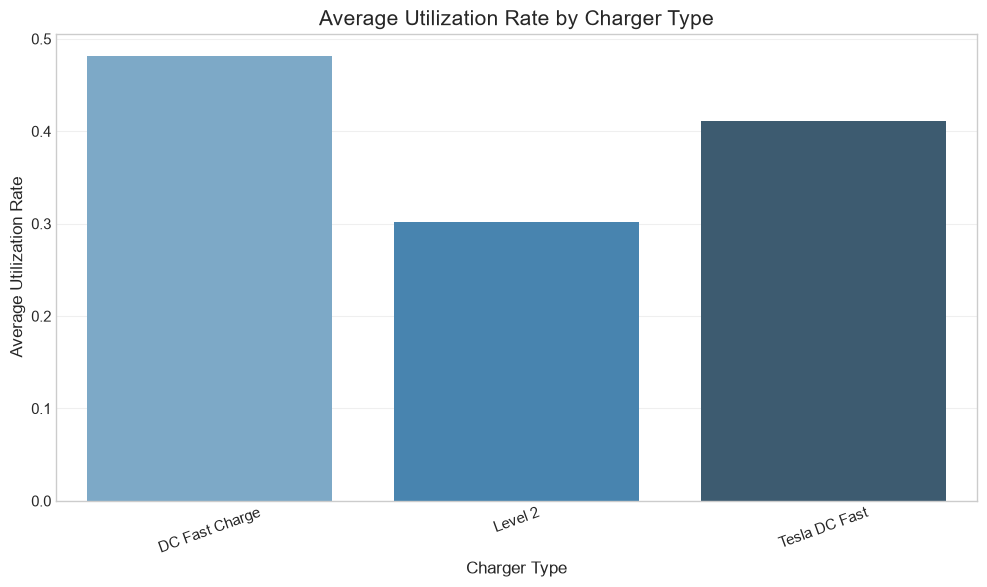

In [8]:
# Calculate average utilization by charger type
utilization_by_charger = (
    df.groupby("charger_type")["utilization_rate"]
      .mean()
      .reset_index()
)

# Create the figure
plt.figure(figsize=(10,6))

# Plot average utilization
sns.barplot(
    data=utilization_by_charger,
    x="charger_type",
    y="utilization_rate",
    palette="Blues_d"
)

# Add labels
plt.title("Average Utilization Rate by Charger Type", fontsize=15)
plt.xlabel("Charger Type", fontsize=12)
plt.ylabel("Average Utilization Rate", fontsize=12)

plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

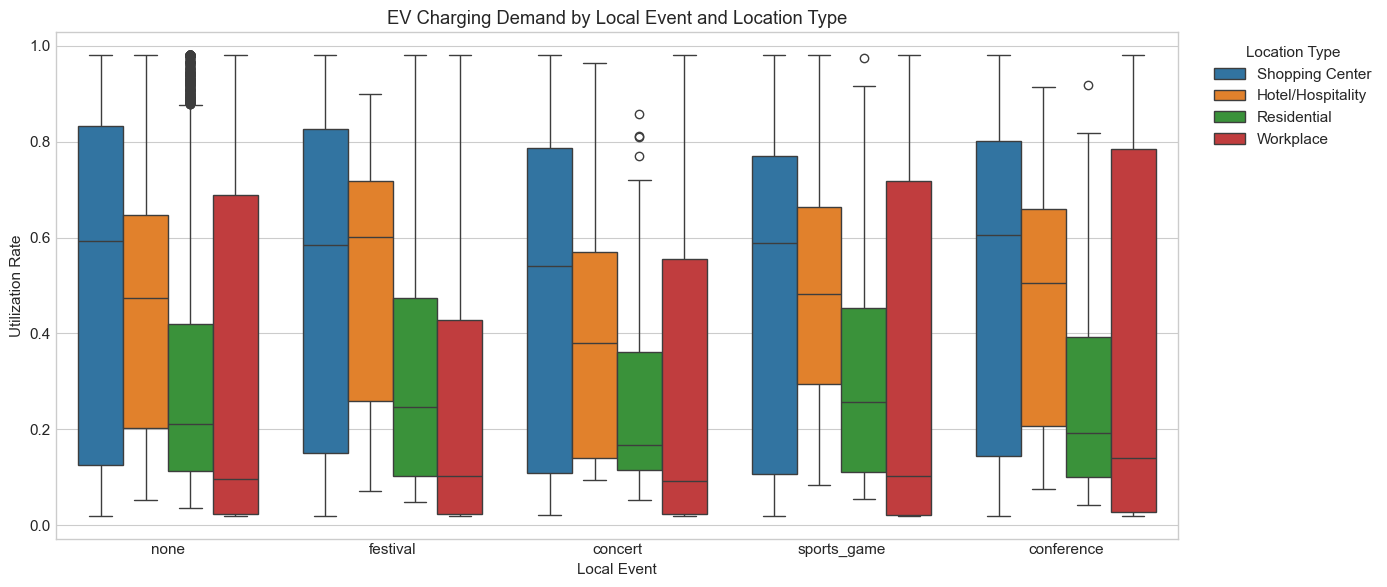

In [14]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="local_event",
    y="utilization_rate",
    hue="location_type"
)

plt.title("EV Charging Demand by Local Event and Location Type")
plt.xlabel("Local Event")
plt.ylabel("Utilization Rate")

plt.legend(
    title="Location Type",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()